# Data Preprocessing — Credit Card Approval Prediction

**DATA 221 — Introduction to Data Science**  
**Team:** Fazel Rabbi, Adi Saifi, Zoya Malik, Siyi Ye  
**Dataset:** Credit Card Approval Prediction (Kaggle)

---

## Purpose of This Notebook

This notebook handles all **shared data preparation** for the project. It loads the raw data, constructs the target variable, cleans the features, and saves a final `cleaned_data.csv` file.

**Every team member's model notebook should start by loading `cleaned_data.csv`** — this guarantees everyone is working from the exact same preprocessed data, which is required for a fair comparison between models.

---

## What This Notebook Does

1. Load and merge the two raw CSV files  
2. Construct the target variable from credit history  
3. Clean and engineer features  
4. Handle missing values  
5. Save the cleaned dataset to `data/cleaned_data.csv`

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Raw Data

Our dataset comes in two files:
- `application_record.csv` — applicant info (demographics, income, employment, etc.)
- `credit_record.csv` — monthly credit payment history per applicant

Both share an `ID` column which we use to link them.

In [2]:
# Load both raw files
app_df    = pd.read_csv('../data/application_record.csv')
credit_df = pd.read_csv('../data/credit_record.csv')

print('Application record:', app_df.shape)
print('Credit record:     ', credit_df.shape)
print()
app_df.head(3)

Application record: (438557, 18)
Credit record:      (1048575, 3)



,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0


In [3]:
# Preview credit record
print('STATUS value counts:')
print(credit_df['STATUS'].value_counts())
print()
credit_df.head()

STATUS value counts:
STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64



,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## Step 3: Construct the Target Variable

The dataset does not come with a ready-made approval/rejection label, so we build one from the payment history.

The `STATUS` column records how overdue each monthly payment was:

| STATUS | Meaning |
|--------|---------|
| `X` | No loan that month |
| `C` | Paid off on time |
| `0` | 1–29 days past due |
| `1` | 30–59 days past due |
| `2` | 60–89 days past due |
| `3` | 90–119 days past due |
| `4` | 120–149 days past due |
| `5` | 150+ days past due |

**Rule:** An applicant is labelled **high risk (1)** if they ever had a payment **30+ days overdue** (STATUS = '1' through '5'). Otherwise they are **low risk (0)**.

We chose 30+ days because using 60+ days produced less than 2% positive examples — far too few for any model to learn from. The 30+ day threshold gives ~11.8% positive class, which is still imbalanced but workable.

In [4]:
# High risk = ever 30+ days overdue
high_risk_statuses = ['1', '2', '3', '4', '5']

credit_df['is_bad'] = credit_df['STATUS'].isin(high_risk_statuses).astype(int)

# Collapse to one row per person (take the worst status they ever had)
risk_per_person = credit_df.groupby('ID')['is_bad'].max().reset_index()
risk_per_person.columns = ['ID', 'TARGET']

n_bad  = risk_per_person['TARGET'].sum()
n_good = len(risk_per_person) - n_bad

print('Target variable distribution:')
print(f'  Low risk  (0): {n_good:,}  ({n_good/len(risk_per_person)*100:.1f}%)')
print(f'  High risk (1): {n_bad:,}   ({n_bad/len(risk_per_person)*100:.1f}%)')

Target variable distribution:
  Low risk  (0): 40,635  (88.4%)
  High risk (1): 5,350   (11.6%)


## Step 4: Merge the Datasets

We merge the application info with our target variable on the shared `ID` column.  
`how='inner'` keeps only applicants who appear in **both** files.

In [5]:
# Merge on ID
df = app_df.merge(risk_per_person, on='ID', how='inner')

print('Merged dataset shape:', df.shape)
print()
print('Columns:', df.columns.tolist())

Merged dataset shape: (36457, 19)

Columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET']


## Step 5: Exploratory Data Analysis

A quick look at the data before we start cleaning.

In [6]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


In [7]:
# Data types and missing values
print('Data types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Data types:
ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
TARGET                   int64
dtype: object

Missing values per column:
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBI

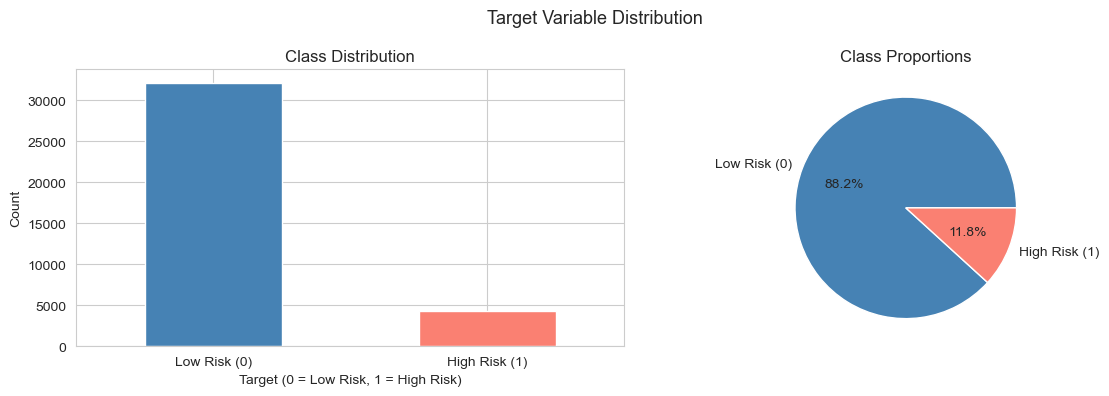

In [8]:
# Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['TARGET'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Target (0 = Low Risk, 1 = High Risk)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'], rotation=0)

# Pie chart
df['TARGET'].value_counts().plot(kind='pie', colors=['steelblue', 'salmon'],
                                  autopct='%1.1f%%', ax=axes[1],
                                  labels=['Low Risk (0)', 'High Risk (1)'])
axes[1].set_title('Class Proportions')
axes[1].set_ylabel('')

plt.suptitle('Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.show()

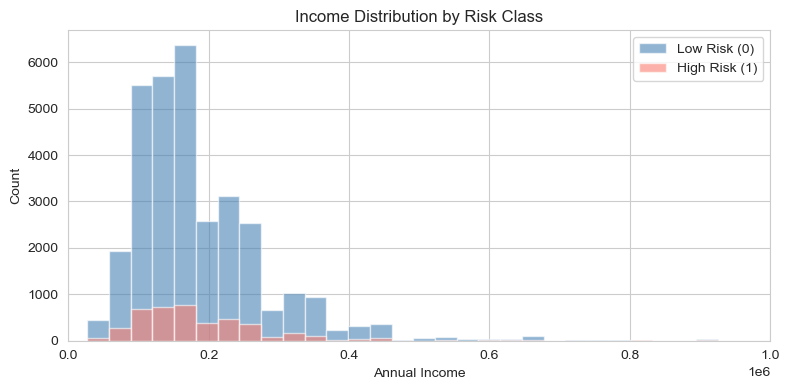

In [9]:
# Income distribution by risk class
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1], ['steelblue', 'salmon']):
    subset = df[df['TARGET'] == label]['AMT_INCOME_TOTAL']
    ax.hist(subset, bins=50, alpha=0.6, color=color,
            label=f'{"Low" if label == 0 else "High"} Risk ({label})')
ax.set_xlabel('Annual Income')
ax.set_ylabel('Count')
ax.set_title('Income Distribution by Risk Class')
ax.set_xlim(0, 1_000_000)
ax.legend()
plt.tight_layout()
plt.show()

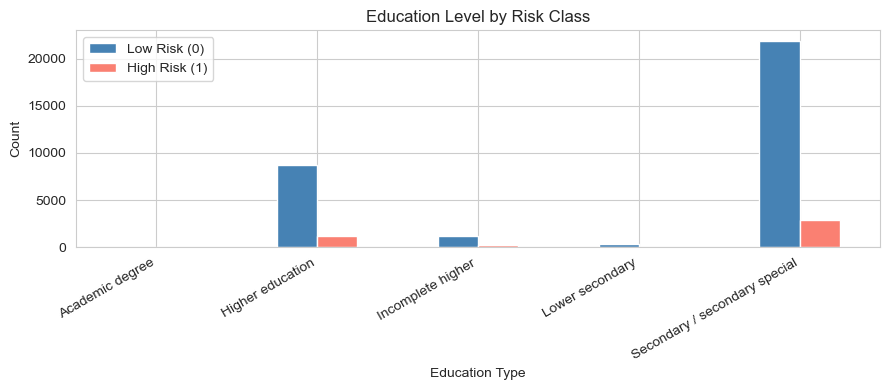

In [10]:
# Education type breakdown
edu_counts = df.groupby(['NAME_EDUCATION_TYPE', 'TARGET']).size().unstack(fill_value=0)
edu_counts.plot(kind='bar', color=['steelblue', 'salmon'], figsize=(9, 4))
plt.title('Education Level by Risk Class')
plt.xlabel('Education Type')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(['Low Risk (0)', 'High Risk (1)'])
plt.tight_layout()
plt.show()

## Step 6: Clean and Engineer Features

We fix a few quirks in the raw data before saving:

- **Drop `ID`** — just an identifier, not a useful feature
- **`DAYS_BIRTH`** — stored as negative days; convert to `AGE` in years
- **`DAYS_EMPLOYED`** — stored as negative days; the value `365243` means unemployed; convert to `YEARS_EMPLOYED`

In [11]:
# Drop ID
df = df.drop(columns=['ID'])

# DAYS_BIRTH → AGE in years (positive)
df['AGE'] = (-df['DAYS_BIRTH']) / 365
df = df.drop(columns=['DAYS_BIRTH'])

# DAYS_EMPLOYED → YEARS_EMPLOYED
# 365243 is a placeholder meaning "unemployed" — replace with 0
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED']) / 365
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].clip(lower=0)
df = df.drop(columns=['DAYS_EMPLOYED'])

print('Cleaned shape:', df.shape)
print('Columns:', df.columns.tolist())

Cleaned shape: (36457, 18)
Columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET', 'AGE', 'YEARS_EMPLOYED']


In [12]:
# Quick summary stats on engineered features
print('AGE stats:')
print(df['AGE'].describe().round(2))
print()
print('YEARS_EMPLOYED stats:')
print(df['YEARS_EMPLOYED'].describe().round(2))

AGE stats:
count    36457.00
mean        43.77
std         11.51
min         20.52
25%         34.14
50%         42.64
75%         53.25
max         68.91
Name: AGE, dtype: float64

YEARS_EMPLOYED stats:
count    36457.00
mean         6.03
std          6.48
min          0.00
25%          1.12
50%          4.25
75%          8.64
max         43.05
Name: YEARS_EMPLOYED, dtype: float64


## Step 7: Save Cleaned Data

We save the cleaned dataset as `cleaned_data.csv` in the `data/` folder.  
All team members should load this file in their own model notebooks.

In [13]:
# Save to data folder
output_path = '../data/cleaned_data.csv'
df.to_csv(output_path, index=False)

print(f'Saved cleaned data to: {output_path}')
print(f'Shape: {df.shape}')
print()
print('Preview of saved file:')
pd.read_csv(output_path).head(3)

Saved cleaned data to: ../data/cleaned_data.csv
Shape: (36457, 18)

Preview of saved file:


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,1,32.890411,12.443836
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,1,32.890411,12.443836
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58.832877,3.106849


In [14]:
# Final summary
print('=' * 50)
print('  DATA PREPROCESSING — COMPLETE')
print('=' * 50)
print(f'  Total applicants:   {len(df):,}')
print(f'  Total features:     {df.shape[1] - 1}  (excluding target)')
print(f'  Low risk  (0):      {(df["TARGET"]==0).sum():,}  ({(df["TARGET"]==0).mean()*100:.1f}%)')
print(f'  High risk (1):      {(df["TARGET"]==1).sum():,}   ({(df["TARGET"]==1).mean()*100:.1f}%)')
print()
print('  Output file: data/cleaned_data.csv')
print()
print('  Next step: Each team member loads cleaned_data.csv')
print('  in their own model notebook and uses random_state=42')
print('  for the train-test split.')
print('=' * 50)

  DATA PREPROCESSING — COMPLETE
  Total applicants:   36,457
  Total features:     17  (excluding target)
  Low risk  (0):      32,166  (88.2%)
  High risk (1):      4,291   (11.8%)

  Output file: data/cleaned_data.csv

  Next step: Each team member loads cleaned_data.csv
  in their own model notebook and uses random_state=42
  for the train-test split.


---

## Notes for Teammates

When you load `cleaned_data.csv` in your model notebook, use this at the top:

```python
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/cleaned_data.csv')

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

The `random_state=42` ensures all four models are evaluated on the **exact same test set**.

**Important:** Fit any encoding or scaling only on `X_train`, then apply to `X_test`. This prevents data leakage.